In [1]:
import pandas as pd

df = pd.read_csv("data/raw/orders.csv")
df.head()


FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/orders.csv'

In [2]:
import os
print(os.getcwd())


/Users/user/ecommerce-finance-project/notebooks


In [3]:
df = pd.read_csv("../data/raw/orders.csv")
df.head()

,order_id,customer_id,order_date,order_amount,status
0,1001,103,2024-01-01 00:00:00,120,paid
1,1002,180,2024-01-01 01:00:00,25,paid
2,1003,93,2024-01-01 02:00:00,199,paid
3,1004,15,2024-01-01 03:00:00,45,created
4,1005,107,2024-01-01 04:00:00,83,paid


In [4]:
df.shape

(1000, 5)

In [5]:
df["status"].value_counts()

status
paid       513
created    487
Name: count, dtype: int64

In [6]:
df["order_amount"].sum()

np.int64(108429)

In [1]:
df.shape

NameError: name 'df' is not defined

In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/orders.csv")

In [3]:
df.shape

(1000, 5)

In [4]:
import pandas as pd

orders = pd.read_csv("../data/raw/orders.csv")
payments = pd.read_csv("../data/raw/payments.csv")

orders.head()

,order_id,customer_id,order_date,order_amount,status
0,1001,103,2024-01-01 00:00:00,120,paid
1,1002,180,2024-01-01 01:00:00,25,paid
2,1003,93,2024-01-01 02:00:00,199,paid
3,1004,15,2024-01-01 03:00:00,45,created
4,1005,107,2024-01-01 04:00:00,83,paid


In [5]:
payments.head()

,payment_id,order_id,payment_date,amount_paid
0,5522,1670,2024-01-22 18:00:00,123
1,5738,1255,2024-01-31 18:00:00,175
2,5741,1477,2024-01-31 21:00:00,34
3,5661,1142,2024-01-28 13:00:00,192
4,5412,1532,2024-01-18 04:00:00,143


In [6]:
merged = orders.merge(payments, on="order_id", how="left")

merged.head()

,order_id,customer_id,order_date,order_amount,status,payment_id,payment_date,amount_paid
0,1001,103,2024-01-01 00:00:00,120,paid,5618.0,2024-01-26 18:00:00,117.0
1,1001,103,2024-01-01 00:00:00,120,paid,5895.0,2024-02-07 07:00:00,170.0
2,1002,180,2024-01-01 01:00:00,25,paid,NaN,NaN,NaN
3,1003,93,2024-01-01 02:00:00,199,paid,NaN,NaN,NaN
4,1004,15,2024-01-01 03:00:00,45,created,NaN,NaN,NaN


In [7]:
merged = orders.merge(payments, on="order_id", how="left")

merged.head()

,order_id,customer_id,order_date,order_amount,status,payment_id,payment_date,amount_paid
0,1001,103,2024-01-01 00:00:00,120,paid,5618.0,2024-01-26 18:00:00,117.0
1,1001,103,2024-01-01 00:00:00,120,paid,5895.0,2024-02-07 07:00:00,170.0
2,1002,180,2024-01-01 01:00:00,25,paid,NaN,NaN,NaN
3,1003,93,2024-01-01 02:00:00,199,paid,NaN,NaN,NaN
4,1004,15,2024-01-01 03:00:00,45,created,NaN,NaN,NaN


In [8]:
missing_payments = merged[merged["amount_paid"].isna()]

missing_payments.head()

,order_id,customer_id,order_date,order_amount,status,payment_id,payment_date,amount_paid
2,1002,180,2024-01-01 01:00:00,25,paid,NaN,NaN,NaN
3,1003,93,2024-01-01 02:00:00,199,paid,NaN,NaN,NaN
4,1004,15,2024-01-01 03:00:00,45,created,NaN,NaN,NaN
5,1005,107,2024-01-01 04:00:00,83,paid,NaN,NaN,NaN
6,1006,72,2024-01-01 05:00:00,78,created,NaN,NaN,NaN


In [9]:
missing_payments = merged[merged["amount_paid"].isna()]

missing_payments.head()

,order_id,customer_id,order_date,order_amount,status,payment_id,payment_date,amount_paid
2,1002,180,2024-01-01 01:00:00,25,paid,NaN,NaN,NaN
3,1003,93,2024-01-01 02:00:00,199,paid,NaN,NaN,NaN
4,1004,15,2024-01-01 03:00:00,45,created,NaN,NaN,NaN
5,1005,107,2024-01-01 04:00:00,83,paid,NaN,NaN,NaN
6,1006,72,2024-01-01 05:00:00,78,created,NaN,NaN,NaN


In [10]:
missing_payments.shape


(447, 8)

In [11]:
paid_but_no_payment = merged[
    (merged["status"] == "paid") & (merged["amount_paid"].isna())
]

paid_but_no_payment.shape

(241, 8)

In [12]:
payment_but_not_paid = merged[
    (merged["status"] == "created") & (merged["amount_paid"].notna())
]

payment_but_not_paid.shape

(423, 8)

In [13]:
amount_mismatch = merged[
    (merged["amount_paid"].notna()) &
    (merged["order_amount"] != merged["amount_paid"])
]

amount_mismatch.head()


,order_id,customer_id,order_date,order_amount,status,payment_id,payment_date,amount_paid
0,1001,103,2024-01-01 00:00:00,120,paid,5618.0,2024-01-26 18:00:00,117.0
1,1001,103,2024-01-01 00:00:00,120,paid,5895.0,2024-02-07 07:00:00,170.0
10,1010,122,2024-01-01 09:00:00,169,created,5075.0,2024-01-04 03:00:00,69.0
12,1012,88,2024-01-01 11:00:00,89,created,5094.0,2024-01-04 22:00:00,96.0
13,1013,117,2024-01-01 12:00:00,131,created,5085.0,2024-01-04 13:00:00,189.0


In [14]:
print("Total Orders:", len(orders))
print("Total Payments:", len(payments))
print("Missing Payments:", len(missing_payments))
print("Paid but No Payment:", len(paid_but_no_payment))
print("Payment but Not Marked Paid:", len(payment_but_not_paid))
print("Amount Mismatches:", len(amount_mismatch))

Total Orders: 1000
Total Payments: 800
Missing Payments: 447
Paid but No Payment: 241
Payment but Not Marked Paid: 423
Amount Mismatches: 798


In [15]:
orders["order_date"] = pd.to_datetime(orders["order_date"])
payments["payment_date"] = pd.to_datetime(payments["payment_date"])

In [16]:
daily_revenue = payments.groupby(payments["payment_date"].dt.date)["amount_paid"].sum()

daily_revenue.head()

payment_date
2024-01-01    1879
2024-01-02    2349
2024-01-03    2164
2024-01-04    1891
2024-01-05    2144
Name: amount_paid, dtype: int64

In [17]:
daily_revenue.plot(title="Daily Revenue")


ImportError: matplotlib is required for plotting when the default backend "matplotlib" is selected.

In [18]:
daily_revenue.plot(title="Daily Revenue")

ImportError: matplotlib is required for plotting when the default backend "matplotlib" is selected.

In [19]:
pip install matplotlib

  Using cached matplotlib-3.10.8-cp314-cp314-macosx_10_13_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp314-cp314-macosx_10_13_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp314-cp314-macosx_10_15_x86_64.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-macosx_10_15_x86_64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp314-cp314-macosx_10_15_x86_64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp314-cp314-macosx_10_13_x86_64.whl (8.3 MB)
Using cached contourpy-1.3.3-cp314-cp314-macosx_10_13_x86_64.whl (292 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp314-cp314-macosx_10_15_x86_64.whl (2.4 MB)
Using cached kiwisolver-1.5.0-cp314-cp314-macosx_10_15_x86_64.whl (66 kB)
Using cached pillow-12.2.0-cp314-cp314-macosx_10_15_x86_64.whl (5.3 MB)
Using cached pyparsi

<Axes: title={'center': 'Daily Revenue'}, xlabel='payment_date'>

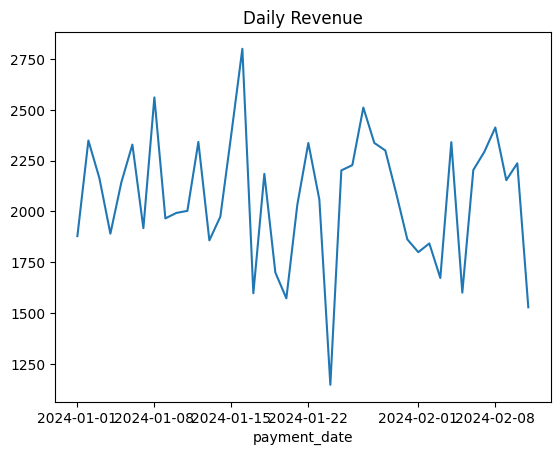

In [20]:
daily_revenue.plot(title="Daily Revenue")

In [21]:
ad_spend = pd.read_csv("../data/raw/ad_spend.csv")
ad_spend["date"] = pd.to_datetime(ad_spend["date"])

In [22]:
daily_ad_spend = ad_spend.groupby(ad_spend["date"].dt.date)["spend"].sum()

In [23]:
finance = pd.DataFrame({
    "revenue": daily_revenue,
    "ad_spend": daily_ad_spend
}).fillna(0)

finance.head()

,revenue,ad_spend
2024-01-01,1879,4420
2024-01-02,2349,4805
2024-01-03,2164,4514
2024-01-04,1891,4108
2024-01-05,2144,4546


In [24]:
finance["roas"] = finance["revenue"] / finance["ad_spend"]
finance.head()

,revenue,ad_spend,roas
2024-01-01,1879,4420,0.425113
2024-01-02,2349,4805,0.488866
2024-01-03,2164,4514,0.479397
2024-01-04,1891,4108,0.460321
2024-01-05,2144,4546,0.471623


In [25]:
expenses = pd.read_csv("../data/raw/expenses.csv")
expenses["date"] = pd.to_datetime(expenses["date"])

In [26]:
daily_expenses = expenses.groupby(expenses["date"].dt.date)["amount"].sum()

In [27]:
finance["expenses"] = daily_expenses
finance = finance.fillna(0)

finance["profit"] = finance["revenue"] - finance["ad_spend"] - finance["expenses"]

finance.head()

,revenue,ad_spend,roas,expenses,profit
2024-01-01,1879,4420,0.425113,1840,-4381
2024-01-02,2349,4805,0.488866,1867,-4323
2024-01-03,2164,4514,0.479397,1995,-4345
2024-01-04,1891,4108,0.460321,1904,-4121
2024-01-05,2144,4546,0.471623,1991,-4393


<Axes: title={'center': 'Daily Profit'}>

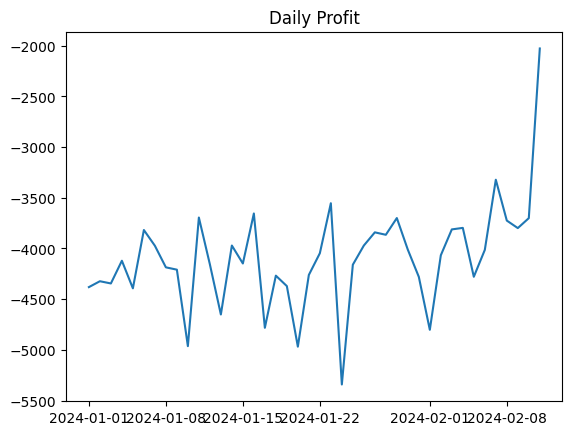

In [28]:
finance["profit"].plot(title="Daily Profit")

In [29]:
import os
os.makedirs("../data/processed", exist_ok=True)

In [30]:
finance = finance.reset_index()
finance.rename(columns={"index": "date"}, inplace=True)

finance.head()

,date,revenue,ad_spend,roas,expenses,profit
0,2024-01-01,1879,4420,0.425113,1840,-4381
1,2024-01-02,2349,4805,0.488866,1867,-4323
2,2024-01-03,2164,4514,0.479397,1995,-4345
3,2024-01-04,1891,4108,0.460321,1904,-4121
4,2024-01-05,2144,4546,0.471623,1991,-4393


In [31]:
finance.to_csv("../data/processed/finance_report.csv", index=False)

In [32]:
finance["date"] = pd.to_datetime(finance["date"]).dt.date

finance.to_csv("../data/processed/finance_report.csv", index=False)

In [33]:
finance["date"] = pd.to_datetime(finance["date"])

In [34]:
finance.to_csv("../data/processed/finance_report.csv", index=False)